In [1]:
# --- figure routing (restructured to match lecture 06) -------------------
import os
try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()          # notebook is run from its own folder
CODE_ROOT = os.path.join(BASE, "..")
FIGROOT = os.path.join(BASE, "01_figures")

# Each figure is saved as PDF into FIGROOT/<slide-folder>/, named by the slide
# it appears on in the exported lecture PDF. Edit numbers/labels here to taste.
SLIDE_MAP = [
    ('histogram_mean_std', '31_dispersion'),
    ('histogram_mean', '29_location'),
    ('boxplot', '31_dispersion'),
    ('cumulative_damages', '26_ecdf'),
    ('disaster_damages', '24_distribution'),
    ('histogram_', '27_binning'),
]

def _folder_for(name):
    """Return the per-slide subfolder for a figure file name."""
    for pat, folder in SLIDE_MAP:
        if pat in name:
            return folder
    return "_unsorted"

def figpath(name):
    """Resolve a figure name to FIGROOT/<slide-folder>/<name>, creating the folder."""
    if not (name.endswith(".pdf") or name.endswith(".gif")):
        name = name + ".pdf"
    folder = os.path.join(FIGROOT, _folder_for(name))
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)
# ------------------------------------------------------------------------

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

directory = "data"
file_name = "1900_2021_DISASTERS.csv"
file_path = os.path.join(BASE,"..", directory, file_name)

df = pd.read_csv(file_path)

figure_path = os.path.join(BASE, '01_figures')
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

# VL 01: Fundamentals Statistic & Probability Theory

In [2]:
df = df.convert_dtypes()
df['Total Damages (US$)'] = df['Total Damages (\'000 US$)'] * 1000

df['date'] = pd.to_datetime(
    dict(
        year=df['Start Year'],
        month=df['Start Month'].fillna(1).astype(int),
        day=df['Start Day'].fillna(1).astype(int)
    ),
    errors='coerce'
)

df['Disaster Type'] = df['Disaster Type'].astype('category')
df.dtypes

Year                                   Int64
Seq                                    Int64
Glide                         string[python]
Disaster Group                string[python]
Disaster Subgroup             string[python]
Disaster Type                       category
Disaster Subtype              string[python]
Disaster Subsubtype           string[python]
Event Name                    string[python]
Country                       string[python]
ISO                           string[python]
Region                        string[python]
Continent                     string[python]
Location                      string[python]
Origin                        string[python]
Associated Dis                string[python]
Associated Dis2               string[python]
OFDA Response                 string[python]
Appeal                        string[python]
Declaration                   string[python]
Aid Contribution                       Int64
Dis Mag Value                          Int64
Dis Mag Sc

# Slide 3 

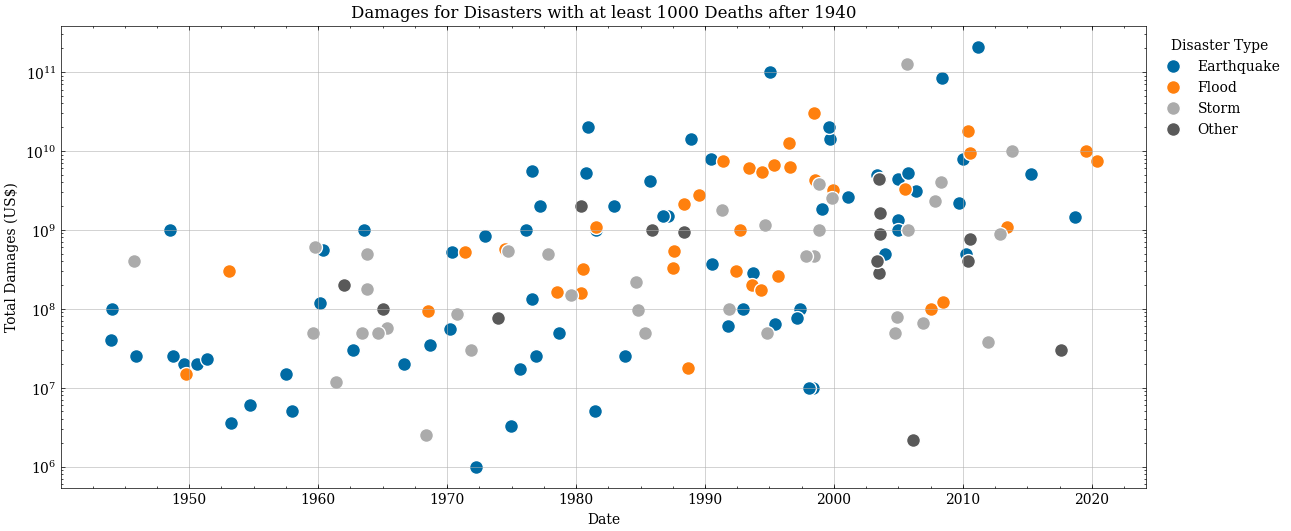

In [3]:
df_subset = df[df['Total Deaths'] >= 1000]
df_subset = df_subset[df_subset["Year"] > 1940]

df_subset['Disaster visual'] = df_subset['Disaster Type'].apply(
    lambda x: x if x in ['Earthquake', 'Flood', 'Storm'] else 'Other'
)

defined_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, disasters in enumerate(['Earthquake', 'Flood', 'Storm', 'Other']):
    plt.scatter(data=df_subset[df_subset['Disaster visual'] == disasters], x='date', y='Total Damages (US$)', s=100, c=defined_colors[i], label=disasters, alpha=1, edgecolors='w', linewidth=1)
plt.title('Damages for Disasters with at least 1000 Deaths after 1940')
plt.xlabel('Date')
plt.ylabel('Total Damages (US$)')
plt.yscale('log')  
plt.legend(title='Disaster Type',bbox_to_anchor=(1.0, 1), loc='upper left')
plt.savefig(figpath('disaster_damages.pdf'), bbox_inches='tight')
plt.show()

# Slide 13

In [4]:
# convert 'Total Deaths' to int, 'Total Damages ('000 US$)' to float
df['Total Deaths'].fillna(0, inplace=True)
df['Total Deaths'] = df['Total Deaths'].astype(int)
df['Total Damages (US$)'] = df['Total Damages (US$)'].astype(float)
df.dtypes

Year                                   Int64
Seq                                    Int64
Glide                         string[python]
Disaster Group                string[python]
Disaster Subgroup             string[python]
Disaster Type                       category
Disaster Subtype              string[python]
Disaster Subsubtype           string[python]
Event Name                    string[python]
Country                       string[python]
ISO                           string[python]
Region                        string[python]
Continent                     string[python]
Location                      string[python]
Origin                        string[python]
Associated Dis                string[python]
Associated Dis2               string[python]
OFDA Response                 string[python]
Appeal                        string[python]
Declaration                   string[python]
Aid Contribution                       Int64
Dis Mag Value                          Int64
Dis Mag Sc

# Slide 17

In [5]:
pd.merge(df['Disaster Type'].value_counts(), (df['Disaster Type'].value_counts()/len(df)).round(2), left_index=True, right_index=True, suffixes=('', '_proportion'))

,count,count_proportion
Disaster Type,,
Flood,5551,0.34
Storm,4496,0.28
Earthquake,1544,0.10
Epidemic,1501,0.09
Landslide,776,0.05
Drought,770,0.05
Extreme temperature,603,0.04
Wildfire,471,0.03
Volcanic activity,265,0.02


# Slide 18

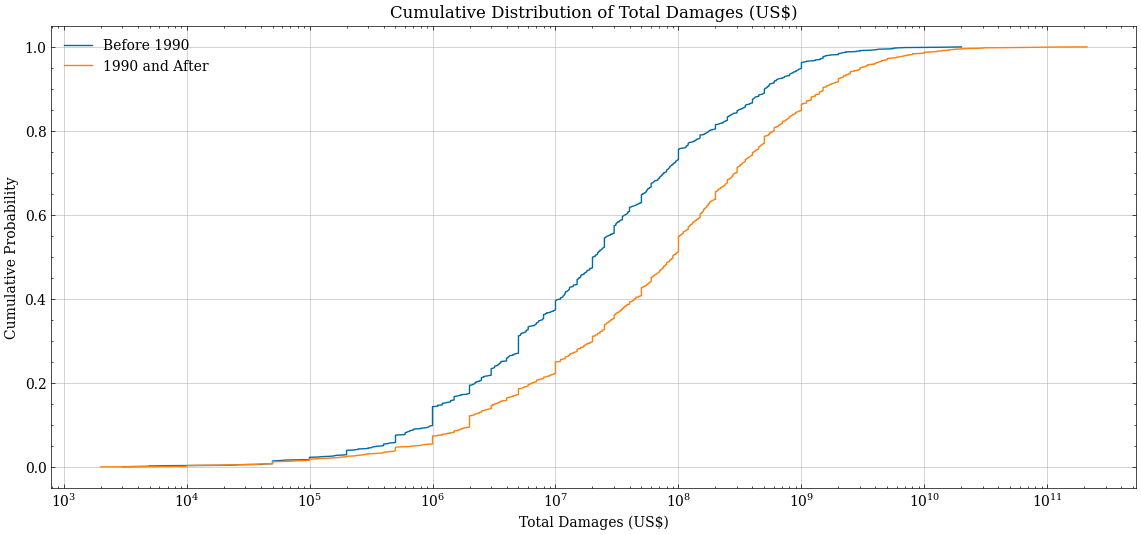

In [6]:
# Split data into before and after 1990
before_1990 = df[df['Year'] < 1990]['Total Damages (US$)'].dropna().values
after_1990 = df[df['Year'] >= 1990]['Total Damages (US$)'].dropna().values

# Sort and compute cumulative probabilities
sorted_before = np.sort(before_1990)
cum_prob_before = np.arange(1, len(sorted_before)+1) / len(sorted_before)

sorted_after = np.sort(after_1990)
cum_prob_after = np.arange(1, len(sorted_after)+1) / len(sorted_after)

plt.plot(sorted_before, cum_prob_before, label='Before 1990')
plt.plot(sorted_after, cum_prob_after, label='1990 and After')
plt.xlabel('Total Damages (US$)')
plt.xscale('log')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Total Damages (US$)')
plt.legend()
plt.savefig(figpath('cumulative_damages.pdf'), bbox_inches='tight')
plt.show()

# Slide 19

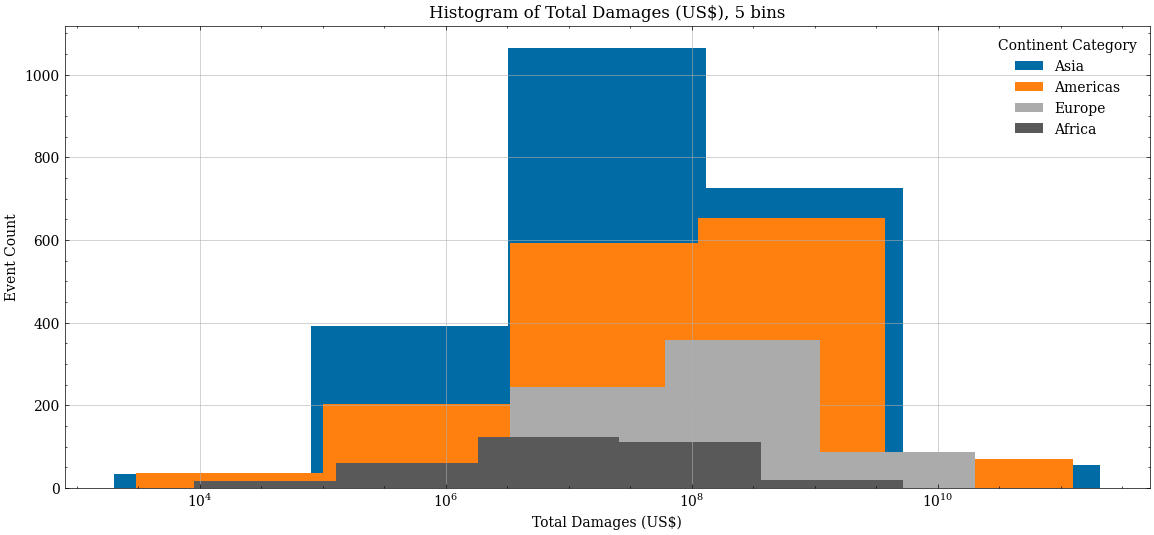

In [7]:
def _plot_histogram(df, diff_column, hist_column, number_bins=100):
    df["Continent Category"] = df["Continent"].apply(
        lambda x: x if x in ["Africa", "Asia", "Americas", "Europe"] else "Other"
    )



    df_plot = df[
        df[hist_column].notna() & np.isfinite(df[hist_column]) & df[diff_column].notna()
    ]
    df_plot = df_plot[df_plot[hist_column] > 0]

    for category in [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
    ]:
        subset = df_plot[df_plot[diff_column] == category]
        log_values = np.log10(subset[hist_column])
        plt.hist(log_values, label=category, bins=number_bins, fill=True, alpha=1)

    plt.title(f"Histogram of {hist_column}, {number_bins} bins")
    plt.xlabel(hist_column)
    plt.xticks(ticks=np.log10([1e4, 1e6, 1e8, 1e10]), labels=['$10^4$', '$10^6$', '$10^8$', '$10^{10}$'])
    plt.ylabel("Event Count")
    plt.legend(title=diff_column)
    plt.savefig(figpath(f'histogram_{hist_column}_{diff_column}_{number_bins}.pdf'), bbox_inches='tight')
    plt.show()

diff_column = "Continent Category"
hist_column = "Total Damages (US$)"

_plot_histogram(df, diff_column, hist_column, number_bins=5)

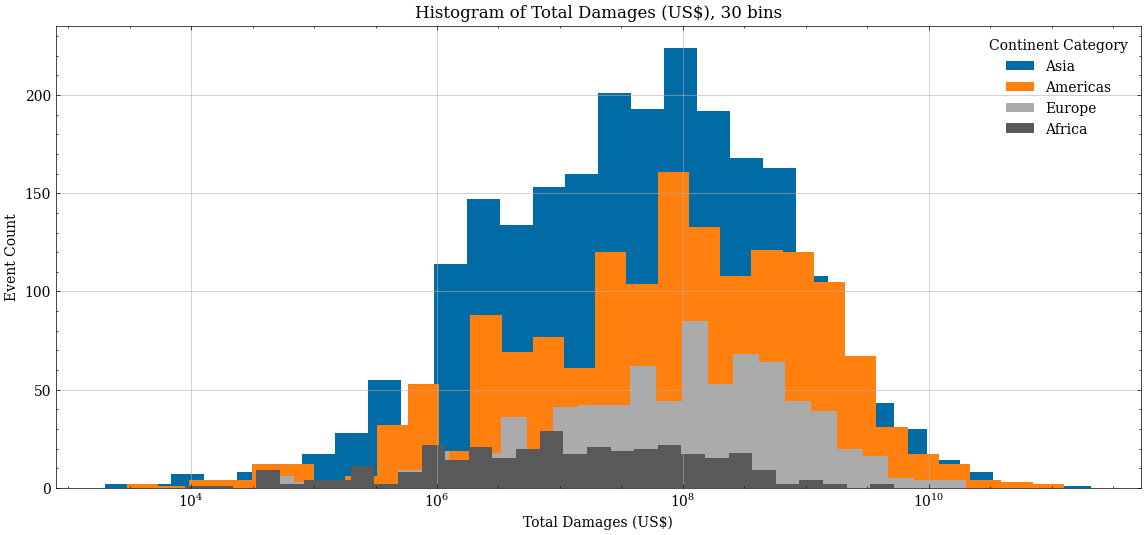

In [8]:
_plot_histogram(df, diff_column, hist_column, number_bins=30)

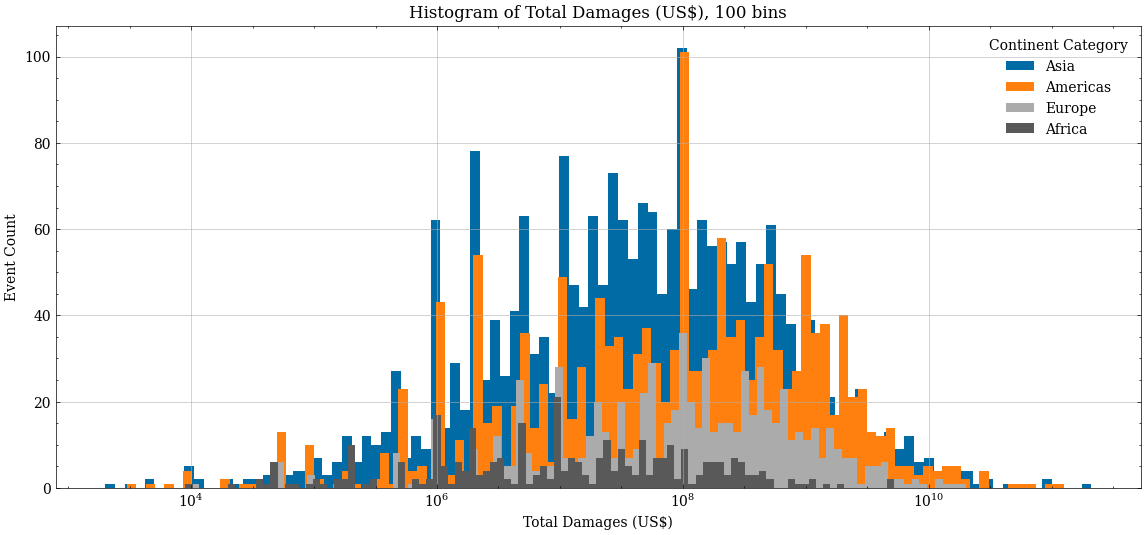

In [9]:
_plot_histogram(df, diff_column, hist_column, number_bins=100)


# Slide 20

/sessions/eloquent-amazing-fermat/tmp/ipykernel_9/844178500.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


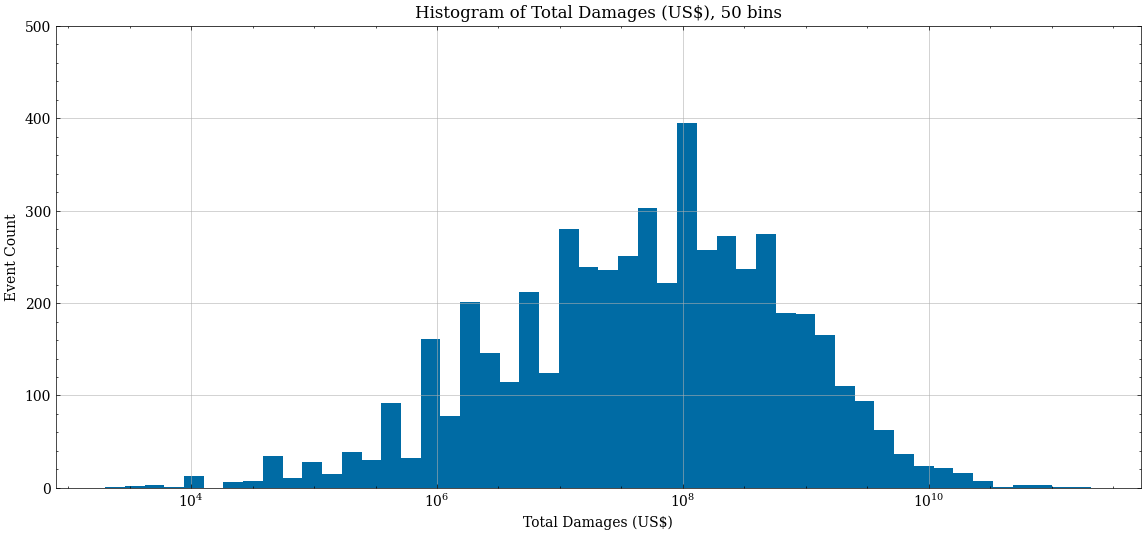

In [10]:
def _plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=False,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title=None,
):
    defined_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    df_plot = df[df[hist_column].notna() & np.isfinite(df[hist_column])]
    df_plot = df_plot[df_plot[hist_column] > 0]
    log_values = np.log10(df[hist_column])

    plt.hist(log_values, bins=number_bins, fill=True, alpha=1)
    plt.title(f"Histogram of {hist_column}, {number_bins} bins")
    plt.xlabel(hist_column)
    plt.xticks(
        ticks=np.log10([1e4, 1e6, 1e8, 1e10]),
        labels=["$10^4$", "$10^6$", "$10^8$", "$10^{10}$"],
    )

    # Location parameter
    if five_percentile:
        five_percentile_value = log_values.quantile(0.05)
        plt.axvline(
            five_percentile_value,
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="5th Percentile",
        )
    if mean:
        mean_value = log_values.mean()
        plt.axvline(
            mean_value,
            color=defined_colors[0],
            linestyle="dashed",
            linewidth=line_width,
            label="Mean",
        )
    if median:
        median_value = log_values.median()
        plt.axvline(
            median_value,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Median",
        )
    if mode:
        mode_value = log_values.mode()[0]
        plt.axvline(
            mode_value,
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="Mode",
        )
    if ninety_five_percentile:
        ninety_five_percentile_value = log_values.quantile(0.95)
        plt.axvline(
            ninety_five_percentile_value,
            color=defined_colors[4],
            linestyle="dashed",
            linewidth=line_width,
            label="95th Percentile",
        )

    # Dispersion parameter
    if std:
        mean_value = log_values.mean()
        std = log_values.std()
        plt.axvline(
            mean_value + std,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Mean +/- Std.",
        )
        plt.axvline(
            mean_value - std,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )
    if iqr:
        interquartile_range = log_values.quantile(0.75) - log_values.quantile(0.25)
        plt.axvline(
            log_values.quantile(0.25),
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="1st/3rd Quartile",
        )
        plt.axvline(
            log_values.quantile(0.75),
            color=defined_colors[3],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )
    if range:
        range_values = (log_values.min(), log_values.max())
        plt.axvline(
            range_values[0],
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="Min/Max",
        )
        plt.axvline(
            range_values[1],
            color=defined_colors[2],
            linestyle="dashed",
            linewidth=line_width,
            label="",
        )

    plt.legend()
    plt.ylim(0, 500)
    plt.ylabel("Event Count")
    plt.savefig(figpath(f'histogram_{title}.pdf'), bbox_inches='tight')
    
    plt.show()


_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=False,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
)

# Slide 21

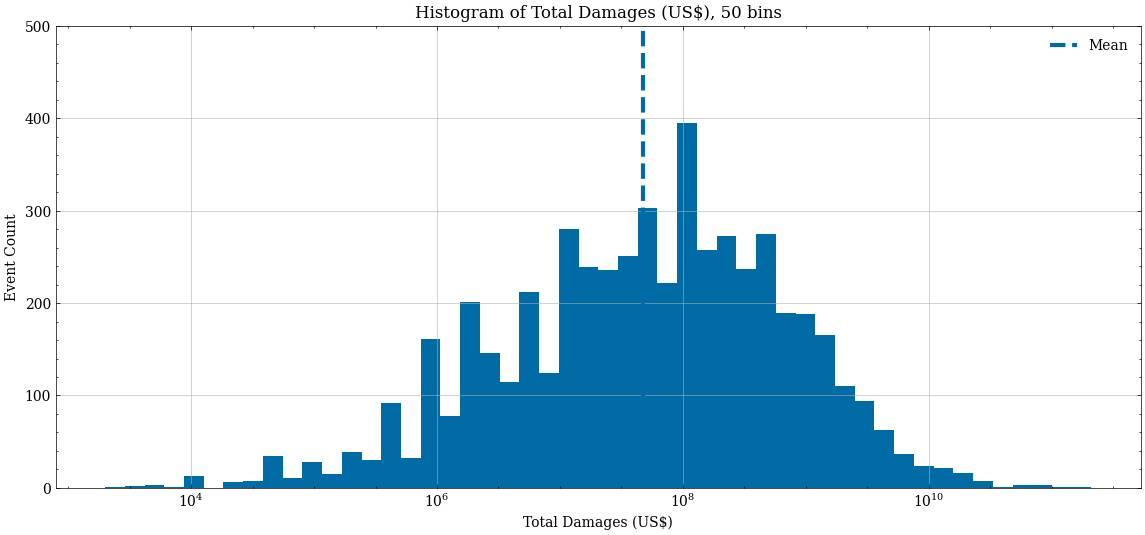

In [11]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=False,
    mean=True,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean"
)

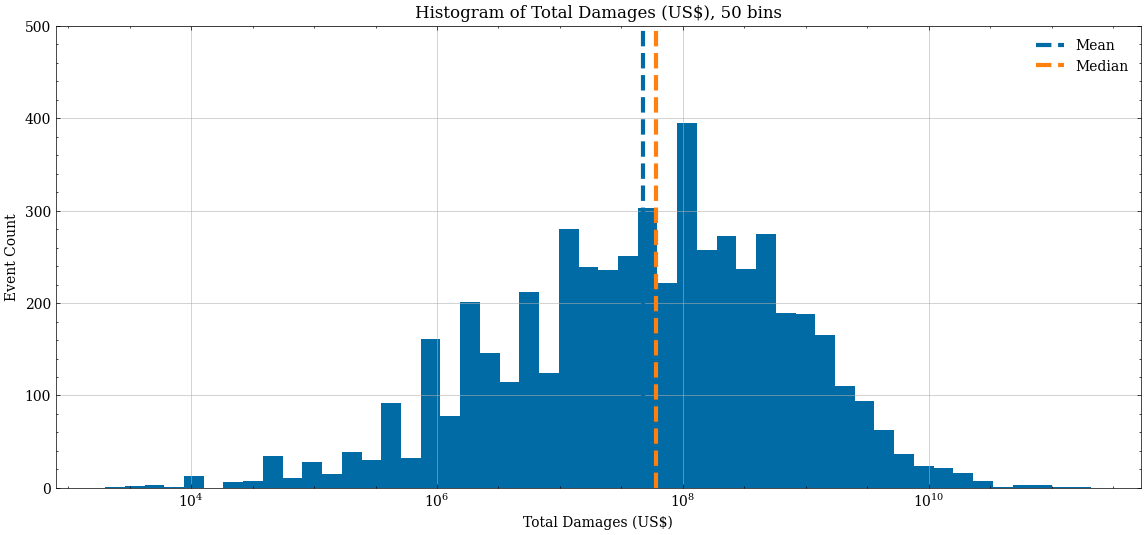

In [12]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=True,
    mean=True,
    mode=False,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median"
)

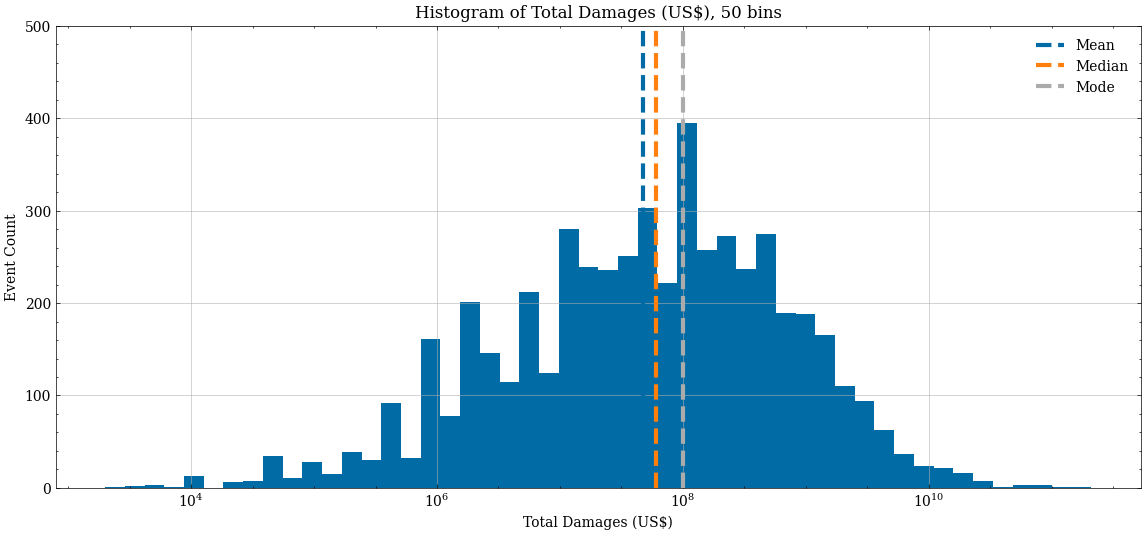

In [13]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=False,
    median=True,
    mean=True,
    mode=True,
    ninety_five_percentile=False,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median_mode"
)

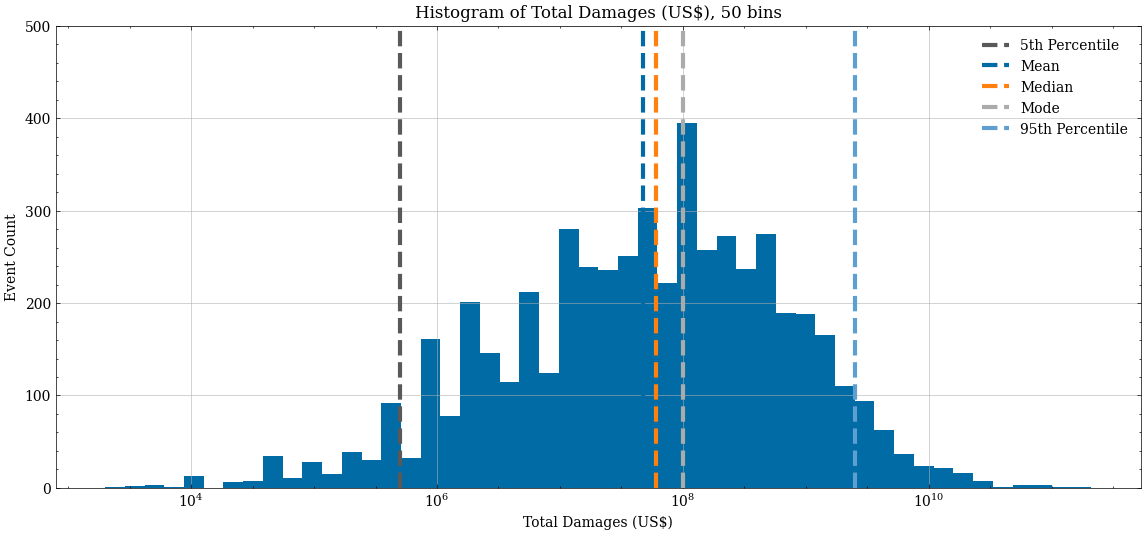

In [14]:
_plot_histogram(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    five_percentile=True,
    median=True,
    mean=True,
    mode=True,
    ninety_five_percentile=True,
    std=False,
    iqr=False,
    range=False,
    line_width=3,
    title="mean_median_mode_percentiles"
)

# Slide 22

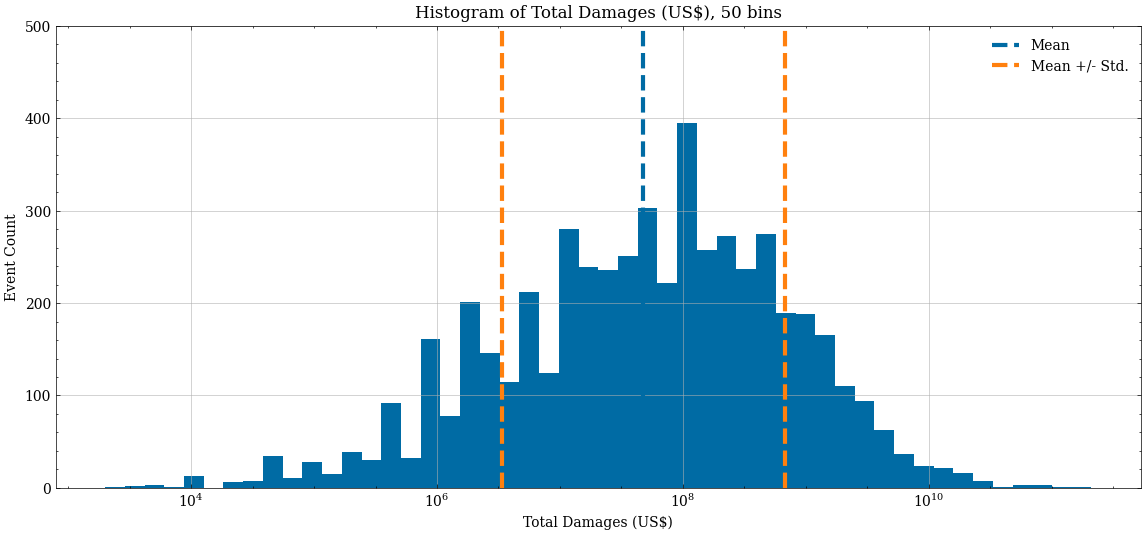

In [15]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=False,
range=False,
line_width=3,
title="mean_std"
)    


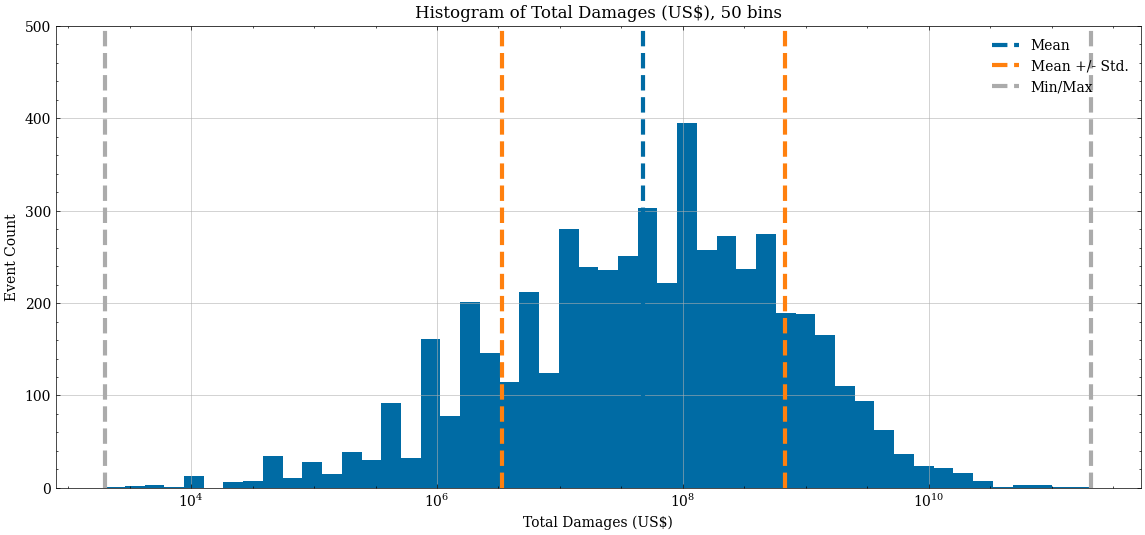

In [16]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=False,
range=True,
line_width=3,
title="mean_std_range"
)    


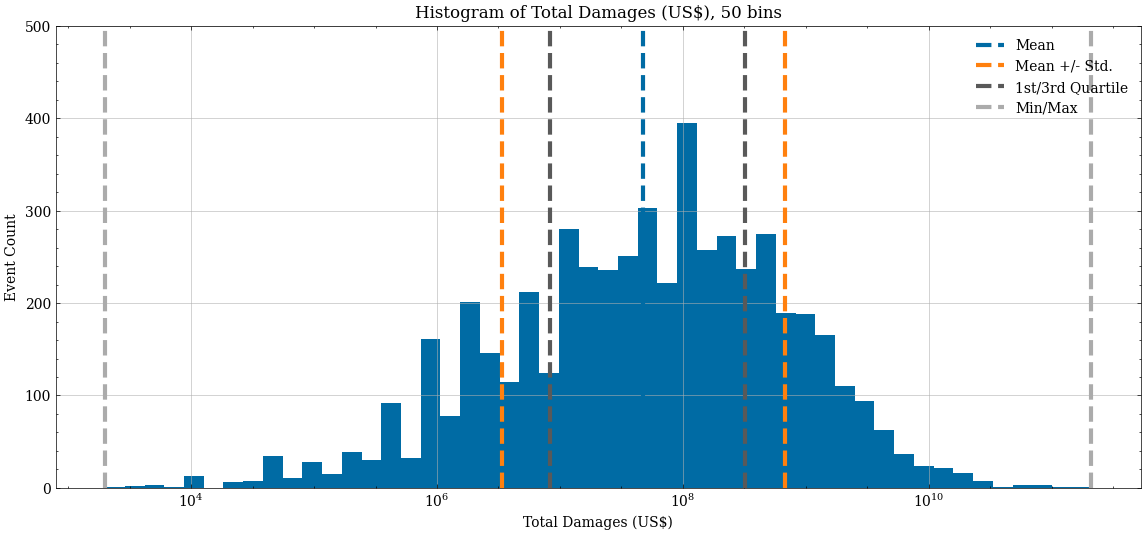

In [17]:
_plot_histogram(
df,
hist_column="Total Damages (US$)",
number_bins=50,
five_percentile=False,
median=False,
mean=True,
mode=False,
ninety_five_percentile=False,
std=True,
iqr=True,
range=True,
line_width=3,
title="mean_std_iqr_range"
)    


# Slide 23

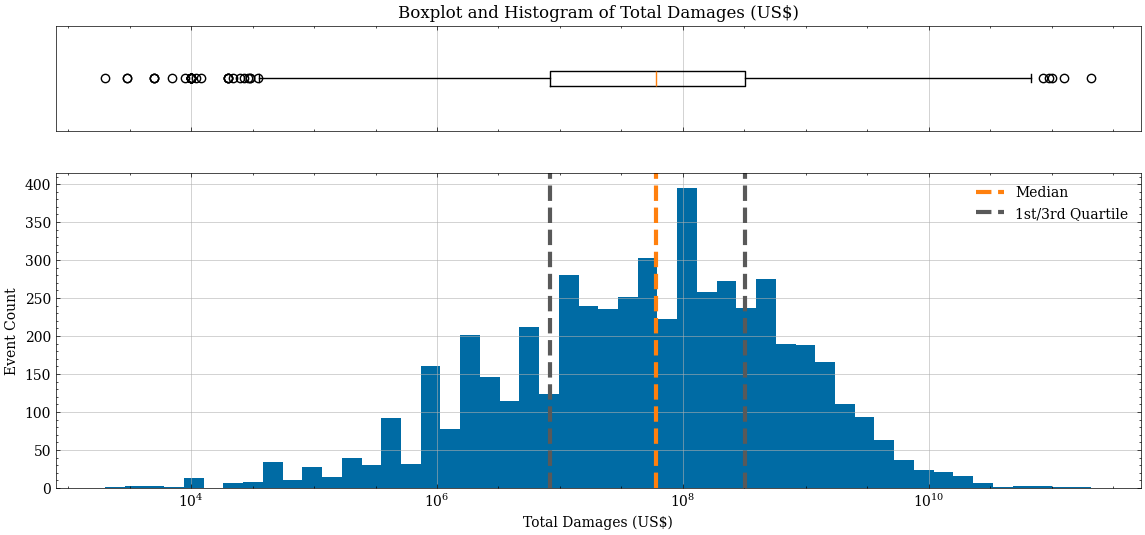

In [18]:
def _plot_boxplot(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
    line_width=3,
):
    df_plot = df[df[hist_column].notna() & np.isfinite(df[hist_column])]
    df_plot = df_plot[df_plot[hist_column] > 0]
    log_values = np.log10(df_plot[hist_column])

    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, ncols=1, sharex=True, gridspec_kw={"height_ratios": [1, 3]}, 
    )

    median_value = log_values.median()
    ax_hist.axvline(
            median_value,
            color=defined_colors[1],
            linestyle="dashed",
            linewidth=line_width,
            label="Median",
        )
    ax_hist.axvline(
        log_values.quantile(0.25),
        color=defined_colors[3],
        linestyle="dashed",
        linewidth=line_width,
        label="1st/3rd Quartile",
    )
    ax_hist.axvline(
        log_values.quantile(0.75),
        color=defined_colors[3],
        linestyle="dashed",
        linewidth=line_width,
        label="",
        )
        
    # Boxplot on top
    ax_box.boxplot(log_values, vert=False)
    ax_box.set(yticks=[], ylabel="")
    ax_box.set_title(f"Boxplot and Histogram of {hist_column}")

    # Histogram below
    ax_hist.hist(log_values, bins=number_bins, fill=True, alpha=1)
    ax_hist.set_xlabel(hist_column)
    ax_hist.set_xticks(np.log10([1e4, 1e6, 1e8, 1e10]))
    ax_hist.set_xticklabels(['$10^4$', '$10^6$', '$10^8$', '$10^{10}$'])
    ax_hist.set_ylabel("Event Count")
    plt.legend()
    plt.savefig(figpath(f'boxplot_histogram_{hist_column}_{number_bins}.pdf'), bbox_inches='tight')
    plt.show()


_plot_boxplot(
    df,
    hist_column="Total Damages (US$)",
    number_bins=50,
)

# Slide 32

In [19]:
df["Continent Category"] = df["Continent"].apply(
        lambda x: x if x in ["Africa", "Asia", "Americas", "Europe"] else "Other"
    )
df["Disaster Category"] = df["Disaster Type"].apply(
    lambda x: x if x in ['Earthquake', 'Flood', 'Storm'] else 'Other'
)

# calculate the bivariate frequency table
df_comparison = df.groupby(["Continent Category", "Disaster Category"]).size().unstack(fill_value=0)
number_events = df_comparison.sum().sum()   

# add the totals as a new column and row
df_comparison['Total'] = df_comparison.sum(axis=1)
df_comparison.loc['Total'] = df_comparison.sum()

# sort columns such that 'Other' is second to last and total is last
cols = ['Earthquake', 'Flood', 'Storm', 'Other', 'Total']
df_comparison = df_comparison[cols]

# calculate relative frequencies
df_comparison_relative = (df_comparison / number_events).round(2)
df_comparison_combined = df_comparison.astype(str) + " (" + df_comparison_relative.astype(str) + ")"

df_comparison_combined

Disaster Category,Earthquake,Flood,Storm,Other,Total
Continent Category,,,,,
Africa,74 (0.0),1147 (0.07),290 (0.02),1435 (0.09),2946 (0.18)
Americas,314 (0.02),1275 (0.08),1442 (0.09),940 (0.06),3971 (0.25)
Asia,903 (0.06),2303 (0.14),1884 (0.12),1400 (0.09),6490 (0.4)
Europe,197 (0.01),668 (0.04),542 (0.03),590 (0.04),1997 (0.12)
Other,56 (0.0),158 (0.01),338 (0.02),170 (0.01),722 (0.04)
Total,1544 (0.1),5551 (0.34),4496 (0.28),4535 (0.28),16126 (1.0)
